Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv('customer_shopping_data.csv')

df.head()



,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


Statistik Deskriptif

In [ ]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


Missing Value

In [ ]:
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


Konversi tanggal

In [ ]:
df['invoice_date'] = pd.to_datetime(
    df['invoice_date'],
    dayfirst=True
)

Buat sales

In [ ]:
df['sales'] = df['quantity'] * df['price']

Agregasi bulanan

In [ ]:
monthly_sales = df.groupby(
    pd.Grouper(
        key='invoice_date',
        freq='ME'
    )
)['sales'].sum().reset_index()

Hapus bulan tidak lengkap

In [ ]:
monthly_sales = monthly_sales.iloc[:-1]

Cek jumlah bulan

In [ ]:
len(monthly_sales)

26

Grafik

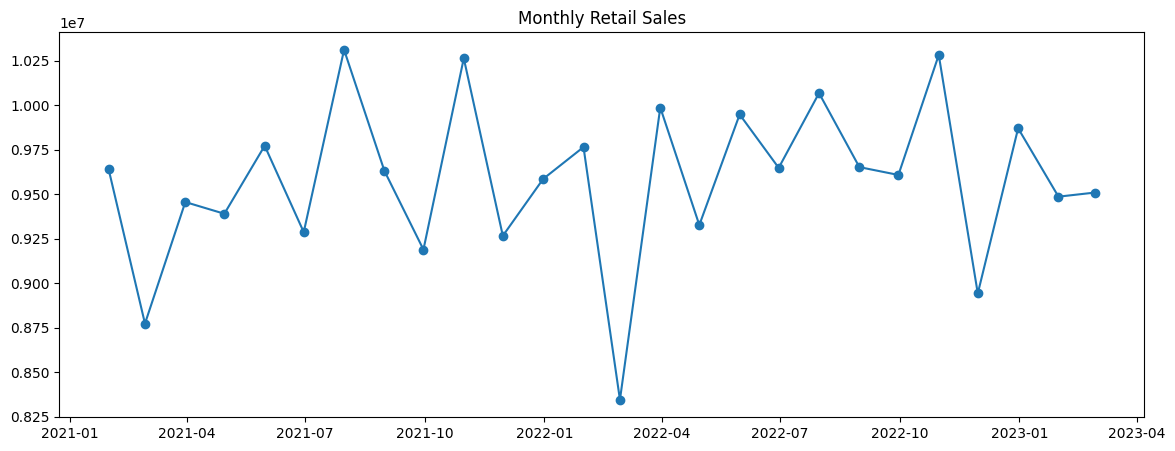

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales['invoice_date'],
    monthly_sales['sales'],
    marker='o'
)

plt.title('Monthly Retail Sales')

plt.show()

Uji Stasioneritas

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales['sales'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -7.43257489062719
p-value: 6.303997937312589e-11


Split Data Kronologis/ Pembagian data

In [ ]:
train = monthly_sales[:22]

test = monthly_sales[22:]

print("Training :", len(train))
print("Testing :", len(test))

Training : 22
Testing : 4


Pelatihan Model Exponential Smoothing

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(
    train['sales'],
    trend='add',
    seasonal=None
)

fit_es = model_es.fit()

pred_es = fit_es.forecast(len(test))

pred_es

,0
22,9.834471e+06
23,9.854770e+06
24,9.875068e+06
25,9.895367e+06


Simpan Hasil Prediksi

In [ ]:
test_es = test.copy()

test_es['Prediksi_ES'] = pred_es.values

test_es

,invoice_date,sales,Prediksi_ES
22,2022-11-30,8941584.66,9.834471e+06
23,2022-12-31,9869885.48,9.854770e+06
24,2023-01-31,9485599.83,9.875068e+06
25,2023-02-28,9508662.96,9.895367e+06


Evaluasi Hitung MAE, RMSE, dan MAPE Exponential Smoothing


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_es = mean_absolute_error(
    test_es['sales'],
    test_es['Prediksi_ES']
)

rmse_es = np.sqrt(
    mean_squared_error(
        test_es['sales'],
        test_es['Prediksi_ES']
    )
)

mape_es = np.mean(
    np.abs(
        (test_es['sales'] - test_es['Prediksi_ES'])
        / test_es['sales']
    )
) * 100

print("MAE :", mae_es)
print("RMSE :", rmse_es)
print("MAPE :", mape_es)

MAE : 421043.7202056339
RMSE : 524094.5075772028
MAPE : 4.57791952857431


Grafik perbandigan Aktual vs Prediksi  Exponential Smoothing

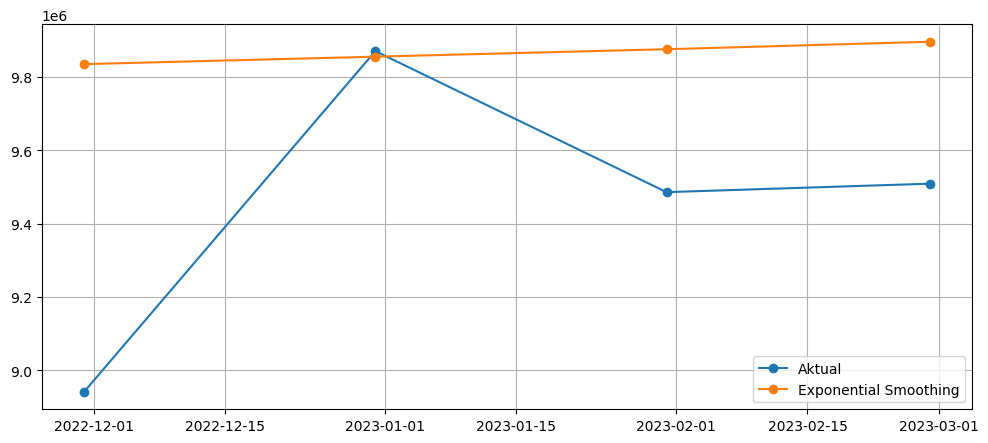

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test_es['invoice_date'],
    test_es['sales'],
    marker='o',
    label='Aktual'
)

plt.plot(
    test_es['invoice_date'],
    test_es['Prediksi_ES'],
    marker='o',
    label='Exponential Smoothing'
)

plt.legend()
plt.grid(True)
plt.show()

Pelatihan Model ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(
    train['sales'],
    order=(1,0,0)
)

fit_arima = model_arima.fit()

pred_arima = fit_arima.forecast(
    steps=len(test)
)

pred_arima

,predicted_mean
22,9.371165e+06
23,9.675633e+06
24,9.573866e+06
25,9.607881e+06


Simpan Hasil Prediksi

In [ ]:
test_arima = test.copy()

test_arima['Prediksi_ARIMA'] = pred_arima.values

test_arima

,invoice_date,sales,Prediksi_ARIMA
22,2022-11-30,8941584.66,9.371165e+06
23,2022-12-31,9869885.48,9.675633e+06
24,2023-01-31,9485599.83,9.573866e+06
25,2023-02-28,9508662.96,9.607881e+06


Evaluasi Hitung MAE, RMSE, MAPE ARIMA

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(
    test_arima['sales'],
    test_arima['Prediksi_ARIMA']
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test_arima['sales'],
        test_arima['Prediksi_ARIMA']
    )
)

mape_arima = np.mean(
    np.abs(
        (test_arima['sales'] - test_arima['Prediksi_ARIMA'])
        / test_arima['sales']
    )
) * 100

print("MAE :", mae_arima)
print("RMSE :", rmse_arima)
print("MAPE :", mape_arima)

MAE : 202829.2337728236
RMSE : 244902.24238817964
MAPE : 2.186601657265127


Grafik perbandingan AKTUAL VS ARIMA

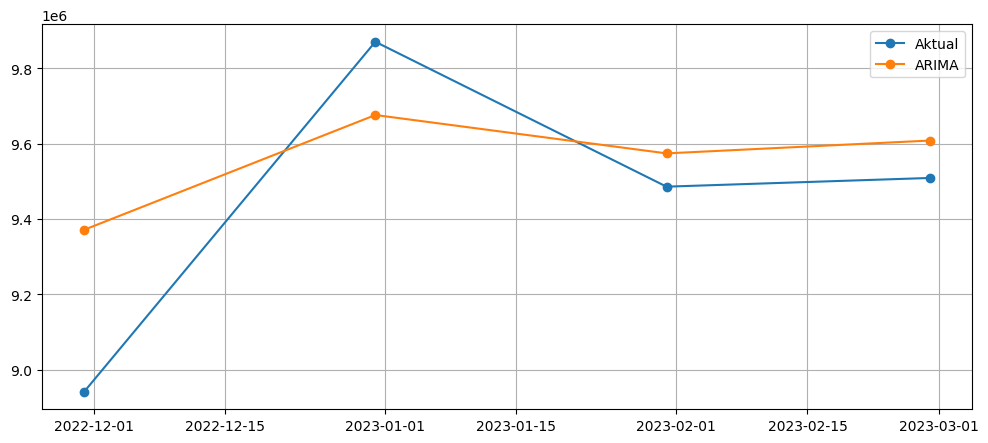

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test_arima['invoice_date'],
    test_arima['sales'],
    marker='o',
    label='Aktual'
)

plt.plot(
    test_arima['invoice_date'],
    test_arima['Prediksi_ARIMA'],
    marker='o',
    label='ARIMA'
)

plt.legend()

plt.grid(True)

plt.show()

Tabel Perbandingan model

In [ ]:
hasil = pd.DataFrame({
    'Model': ['Exponential Smoothing', 'ARIMA'],
    'MAE': [mae_es, mae_arima],
    'RMSE': [rmse_es, rmse_arima],
    'MAPE': [mape_es, mape_arima]
})

hasil

,Model,MAE,RMSE,MAPE
0,Exponential Smoothing,421043.720206,524094.507577,4.577920
1,ARIMA,202829.233773,244902.242388,2.186602


Prediksi Bulan Berikutnya

In [ ]:
forecast_next = fit_arima.forecast(steps=1)

print(
    "Prediksi Penjualan Bulan Berikutnya :",
    round(forecast_next.iloc[0],2)
)

Prediksi Penjualan Bulan Berikutnya : 9371164.99


Missing Timestamp

In [ ]:
monthly_sales['invoice_date']

,invoice_date
0,2021-01-31
1,2021-02-28
2,2021-03-31
3,2021-04-30
4,2021-05-31
5,2021-06-30
6,2021-07-31
7,2021-08-31
8,2021-09-30
9,2021-10-31


Analisis Residual ARIMA

In [ ]:
residuals = test_arima['sales'] - test_arima['Prediksi_ARIMA']

print(residuals)

22   -429580.328237
23    194252.609205
24    -88265.958802
25    -99218.038848
dtype: float64


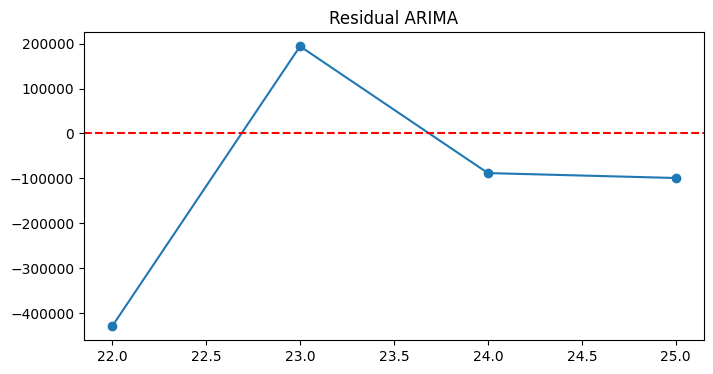

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    residuals,
    marker='o'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title('Residual ARIMA')

plt.show()